# 16 — Seed-variance check on the unfrozen augmented run

The unfrozen augmented run from Phase 12 (`augmented_unfrozen`, seed=42) gave 0.681 overall macro-F1 — lower than the unfrozen baseline (0.738), the unexpected finding that synthetic data hurts once the backbone is unfrozen. That number rested on a single seed. Notebook 15 put a ±0.04 band on the unfrozen baseline; here we did the same for the unfrozen augmented arm and put a noise bound under the "augmentation hurts the unfrozen model" claim.
**Setup.** Exact same recipe as `12_train_unfrozen_ablation.ipynb`, augmented arm only:

- ResNet50, backbone **unfrozen**
- two-LR optimiser — backbone `1e-5`, head `1e-4`
- batch 16, 20 epochs, patience 5
- ReduceLROnPlateau on val loss
- class-weighted CE loss from real train counts
- training data = real + CVAE synthetic for BCC, AKIEC, DF, VASC (same `SOURCES_PER_CLASS` as Phase 10 / Phase 12)

**One change:** `SEED = 123` instead of `SEED = 42`. Everything else identical.

## 1. Imports, paths, seed

In [1]:
import sys
from pathlib import Path
import csv
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, recall_score, accuracy_score,
)

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import ISICDataset, CLASS_NAMES, get_class_weights        # noqa: E402
from src.dataset_augmented import AugmentedISICDataset                      # noqa: E402
from src.models.classifier import build_resnet50_classifier                 # noqa: E402

# Paths
SPLITS_CSV = PROJECT_ROOT / 'data' / 'processed' / 'splits.csv'
IMAGES_DIR = PROJECT_ROOT / 'data' / 'raw' / 'ISIC2018_Task3_Training_Input'
MANIFEST   = PROJECT_ROOT / 'data' / 'synthetic' / 'synthetic_manifest.csv'

RESULTS    = PROJECT_ROOT / 'results'
CKPT_DIR   = RESULTS / 'checkpoints'
LOGS_DIR   = RESULTS / 'logs'
PLOTS_DIR  = RESULTS / 'plots'
for d in (CKPT_DIR, LOGS_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert SPLITS_CSV.exists(), f'splits.csv not found at {SPLITS_CSV}'
assert IMAGES_DIR.exists(), f'images dir not found at {IMAGES_DIR}'
assert MANIFEST.exists(),   f'synthetic_manifest.csv not found at {MANIFEST}. Run Phase 8 first.'

# Seed everything — this is the only thing that changes vs Phase 12 augmented arm
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'Seed fixed to {SEED}')

Seed fixed to 123


## 2. Device check

Full fine-tuning on CPU is not realistic — one epoch of ResNet50 with the backbone unfrozen takes hours on CPU versus about 1.5 minutes on a GPU. We ran this notebook on GPU.

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: no GPU detected. Full fine-tuning is not feasible on CPU.')

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
CUDA memory: 85.1 GB


## 3. Hyperparameters

Identical to the Phase 12 augmented-unfrozen run.

In [3]:
IMG_SIZE      = 224
BATCH_SIZE    = 16        # smaller than frozen runs because unfrozen ResNet50 uses ~2x memory
EPOCHS        = 20
LR_BACKBONE   = 1e-5      # gentle — pretrained features should drift slowly
LR_HEAD       = 1e-4      # standard — randomly initialised, needs to move
WEIGHT_DECAY  = 1e-4
PATIENCE      = 5
NUM_WORKERS   = 2
N_CLASSES     = len(CLASS_NAMES)

# Same per-class source mapping as Phase 10 / Phase 12
SOURCES_PER_CLASS = {
    2: 'cvae',    # BCC
    3: 'cvae',    # AKIEC
    5: 'cvae',    # DF
    6: 'cvae',    # VASC
}

print(f'image size      : {IMG_SIZE}')
print(f'batch size      : {BATCH_SIZE}')
print(f'epochs          : {EPOCHS}')
print(f'lr (backbone)   : {LR_BACKBONE}')
print(f'lr (head)       : {LR_HEAD}')
print(f'patience        : {PATIENCE}')
print(f'sources per cls : {SOURCES_PER_CLASS}')

image size      : 224
batch size      : 16
epochs          : 20
lr (backbone)   : 1e-05
lr (head)       : 0.0001
patience        : 5
sources per cls : {2: 'cvae', 3: 'cvae', 5: 'cvae', 6: 'cvae'}


## 4. Transforms

Identical to Phase 12.

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
print('transforms ready')

transforms ready


## 5. Datasets and loaders

Augmented training set (real + CVAE synthetic) — same `SOURCES_PER_CLASS` as Phase 12.

In [5]:
train_ds = AugmentedISICDataset(
    splits_csv=SPLITS_CSV, images_dir=IMAGES_DIR,
    synth_manifest_csv=MANIFEST, project_root=PROJECT_ROOT,
    split='train', transform=train_tf,
    sources_per_class=SOURCES_PER_CLASS,
)
val_ds   = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='val',   transform=eval_tf)
test_ds  = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='test',  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Count how many synthetic samples were added (for sanity)
real_train_count = len(ISICDataset(SPLITS_CSV, IMAGES_DIR, split='train'))
synth_added = len(train_ds) - real_train_count
print(f'train (augmented) : {len(train_ds):>6,}  (real {real_train_count:,} + synthetic {synth_added:,})')
print(f'val               : {len(val_ds):>6,}')
print(f'test              : {len(test_ds):>6,}')

train (augmented) : 11,145  (real 7,009 + synthetic 4,136)
val               :  1,503
test              :  1,503


## 6. Class weights

Same as Phase 5 / 10 / 12 — computed from real train counts. Using real counts keeps the loss landscape comparable across every run in the project.

In [6]:
class_weights = get_class_weights(SPLITS_CSV, split='train').to(DEVICE)

print('class weights (real train, inverse frequency):')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<6} idx={i}  weight={class_weights[i].item():.4f}')

class weights (real train, inverse frequency):
  MEL    idx=0  weight=1.2853
  NV     idx=1  weight=0.2134
  BCC    idx=2  weight=2.7813
  AKIEC  idx=3  weight=4.3724
  BKL    idx=4  weight=1.3021
  DF     idx=5  weight=12.5161
  VASC   idx=6  weight=10.1140


## 7. EarlyStopping helper

Same logic as every other training notebook in the project.

In [7]:
class EarlyStopping:
    # Stops training when validation loss stops improving for `patience` consecutive epochs.

    def __init__(self, patience: int = 5, delta: float = 0.0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss: float):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True

## 8. Train / evaluate helpers

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0; correct = 0; total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0; correct = 0; total = 0
    all_preds = []; all_labels = []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(y.cpu().tolist())
    avg_loss = total_loss / total
    acc = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    bal_acc  = balanced_accuracy_score(all_labels, all_preds)
    return avg_loss, acc, macro_f1, bal_acc, all_preds, all_labels

## 9. Model, optimiser, loss

Backbone unfrozen, two-LR Adam. Same construction as Phase 12.

In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Build model with backbone UNFROZEN
model = build_resnet50_classifier(num_classes=N_CLASSES, freeze_backbone=False).to(DEVICE)

# Two parameter groups — backbone gentle, head normal
backbone_params = [p for n, p in model.named_parameters() if not n.startswith('fc.')]
head_params     = [p for n, p in model.named_parameters() if n.startswith('fc.')]
optimizer = torch.optim.Adam([
    {'params': backbone_params, 'lr': LR_BACKBONE},
    {'params': head_params,     'lr': LR_HEAD},
], weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2,
)

n_total = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'total params     : {n_total:>11,}')
print(f'trainable params : {n_train:>11,}  ({100*n_train/n_total:.2f}%)')
print(f'backbone params  : {sum(p.numel() for p in backbone_params):>11,} @ lr={LR_BACKBONE}')
print(f'head     params  : {sum(p.numel() for p in head_params):>11,} @ lr={LR_HEAD}')

total params     :  23,522,375
trainable params :  23,522,375  (100.00%)
backbone params  :  23,508,032 @ lr=1e-05
head     params  :      14,343 @ lr=0.0001


## 10. Training loop

Logs to CSV, saves best checkpoint by val macro-F1, early-stops on val loss.

In [10]:
EXPERIMENT_NAME = 'augmented_unfrozen_seed123'
log_path  = LOGS_DIR / f'{EXPERIMENT_NAME}_log.csv'
ckpt_path = CKPT_DIR / f'{EXPERIMENT_NAME}_best.pt'

early_stopper = EarlyStopping(patience=PATIENCE)

with open(log_path, 'w', newline='') as f:
    csv.writer(f).writerow(
        ['epoch', 'train_loss', 'train_acc', 'val_loss',
         'val_acc', 'val_macro_f1', 'val_balanced_acc', 'lr_backbone', 'lr_head']
    )

history = {k: [] for k in
           ['epoch', 'train_loss', 'train_acc',
            'val_loss', 'val_acc', 'val_macro_f1', 'val_balanced_acc']}
best_val_f1 = -1.0
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    ep_start = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc, val_f1, val_bal, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    lr_bb = optimizer.param_groups[0]['lr']
    lr_hd = optimizer.param_groups[1]['lr']

    history['epoch'].append(epoch)
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_macro_f1'].append(val_f1)
    history['val_balanced_acc'].append(val_bal)

    with open(log_path, 'a', newline='') as f:
        csv.writer(f).writerow(
            [epoch, tr_loss, tr_acc, val_loss, val_acc, val_f1, val_bal, lr_bb, lr_hd]
        )

    marker = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'val_macro_f1': val_f1}, ckpt_path)
        marker = '  <-- new best, saved'

    dt = time.time() - ep_start
    print(f'epoch {epoch:>2}/{EPOCHS}  '
          f'train_loss={tr_loss:.4f} acc={tr_acc:.4f}  '
          f'val_loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f}  '
          f'lr_bb={lr_bb:.1e}  ({dt:.1f}s){marker}')

    early_stopper.check_early_stop(val_loss)
    if early_stopper.stop_training:
        print(f'early stopping at epoch {epoch}')
        break

total = time.time() - t0
print(f'\ntraining done in {total/60:.1f} min, best val_macro_f1={best_val_f1:.4f}')
print(f'checkpoint -> {ckpt_path}')
print(f'log        -> {log_path}')

epoch  1/20  train_loss=1.4703 acc=0.2573  val_loss=1.6192 acc=0.6114 f1=0.3982  lr_bb=1.0e-05  (58.5s)  <-- new best, saved
epoch  2/20  train_loss=1.1731 acc=0.5166  val_loss=1.2294 acc=0.6467 f1=0.4660  lr_bb=1.0e-05  (53.8s)  <-- new best, saved
epoch  3/20  train_loss=1.0220 acc=0.5558  val_loss=1.0244 acc=0.6647 f1=0.5223  lr_bb=1.0e-05  (53.9s)  <-- new best, saved
epoch  4/20  train_loss=0.9417 acc=0.5823  val_loss=0.8932 acc=0.7046 f1=0.5718  lr_bb=1.0e-05  (53.9s)  <-- new best, saved
epoch  5/20  train_loss=0.8792 acc=0.6007  val_loss=0.8334 acc=0.7399 f1=0.5887  lr_bb=1.0e-05  (54.2s)  <-- new best, saved
epoch  6/20  train_loss=0.8317 acc=0.6190  val_loss=0.7734 acc=0.7053 f1=0.6058  lr_bb=1.0e-05  (54.1s)  <-- new best, saved
epoch  7/20  train_loss=0.7918 acc=0.6267  val_loss=0.7408 acc=0.7525 f1=0.6419  lr_bb=1.0e-05  (54.0s)  <-- new best, saved
epoch  8/20  train_loss=0.7633 acc=0.6345  val_loss=0.7365 acc=0.7405 f1=0.6063  lr_bb=1.0e-05  (53.6s)
epoch  9/20  train_lo

## 11. Training curves

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/augmented_unfrozen_seed123_curves.png


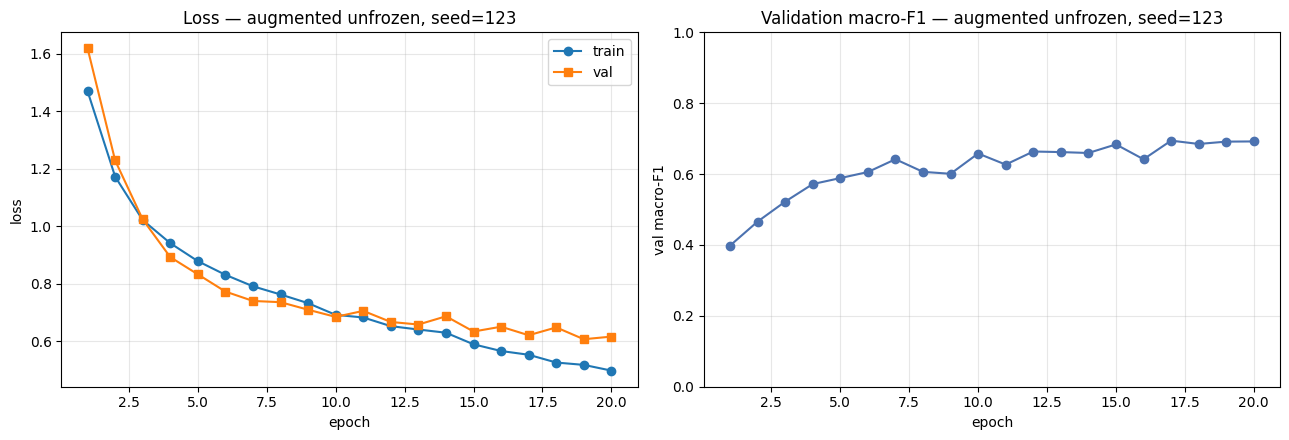

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history['epoch'], history['train_loss'], marker='o', label='train')
axes[0].plot(history['epoch'], history['val_loss'],   marker='s', label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].set_title('Loss — augmented unfrozen, seed=123')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch'], history['val_macro_f1'], marker='o', color='#4C72B0')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val macro-F1')
axes[1].set_title('Validation macro-F1 — augmented unfrozen, seed=123')
axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 1)

plt.tight_layout()
out = PLOTS_DIR / 'augmented_unfrozen_seed123_curves.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

Both losses fall together for the first ten epochs, then train loss keeps dropping while val loss flattens around 0.6 — mild overfit, same shape as the seed=42 augmented-unfrozen run. Val macro-F1 climbs steadily to around 0.69 and the best checkpoint lands at epoch 17 (val macro-F1 = 0.6944).

## 12. Test-set evaluation

We loaded the best checkpoint and evaluated it on the held-out test set.

In [12]:
model_eval = build_resnet50_classifier(num_classes=N_CLASSES, freeze_backbone=False).to(DEVICE)
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
model_eval.load_state_dict(ckpt['model_state_dict'])
print(f'loaded epoch {ckpt["epoch"]}  (val macro-F1 = {ckpt["val_macro_f1"]:.4f})')

test_loss, test_acc, test_f1, test_bal, test_preds, test_labels = evaluate(
    model_eval, test_loader, criterion, DEVICE,
)
print(f'test_loss        = {test_loss:.4f}')
print(f'test_accuracy    = {test_acc:.4f}')
print(f'test_macro_f1    = {test_f1:.4f}')
print(f'test_balanced_acc= {test_bal:.4f}')

loaded epoch 17  (val macro-F1 = 0.6944)
test_loss        = 0.7108
test_accuracy    = 0.7964
test_macro_f1    = 0.6859
test_balanced_acc= 0.7528


Test macro-F1 = **0.6859**, balanced accuracy = 0.7528. Very close to the seed=42 number (0.681) — the augmented-unfrozen arm reproduces under a new seed.

## 13. Seed-variance summary — augmented unfrozen, seed=42 vs seed=123

Compares the Phase 12 augmented-unfrozen result (seed=42, 0.681) against this run (seed=123) class by class. The `diff` column is the per-class delta between the two seeds.

In [13]:
# Per-class recall from this seed=123 run
rec_seed123 = recall_score(test_labels, test_preds,
                           labels=list(range(N_CLASSES)),
                           average=None, zero_division=0)

# Pull the seed=42 numbers from the Phase 12 comparison CSV
phase12_csv = LOGS_DIR / 'comparison_unfrozen_baseline_vs_augmented.csv'

if phase12_csv.exists():
    phase12 = pd.read_csv(phase12_csv)
    # the augmented-unfrozen recalls from Phase 12 live in 'augmented_unfrozen_recall'
    rec_seed42 = phase12.set_index('class')['augmented_unfrozen_recall']

    rows = []
    for i, name in enumerate(CLASS_NAMES):
        s42 = rec_seed42.get(name, float('nan'))
        s123 = rec_seed123[i]
        rows.append({
            'class':         name,
            'seed42_recall': s42,
            'seed123_recall': s123,
            'diff':          s123 - s42,
        })
    # Overall row uses macro-F1, not recall
    s42_overall  = float(rec_seed42.get('OVERALL', float('nan')))
    s123_overall = test_f1
    rows.append({
        'class': 'OVERALL',
        'seed42_recall':  s42_overall,
        'seed123_recall': s123_overall,
        'diff':           s123_overall - s42_overall,
    })

    seed_variance_df = pd.DataFrame(rows)
    print(seed_variance_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

    out_csv = LOGS_DIR / 'seed_variance_augmented_unfrozen.csv'
    seed_variance_df.to_csv(out_csv, index=False)
    print(f'\nsaved {out_csv}')
else:
    print(f'Phase 12 comparison CSV not found at {phase12_csv}.')
    print('Run notebook 12 first, or compare manually against its results summary.')

  class  seed42_recall  seed123_recall   diff
    MEL          0.689           0.593 -0.096
     NV          0.826           0.846  0.020
    BCC          0.792           0.831  0.039
  AKIEC          0.653           0.612 -0.041
    BKL          0.685           0.727  0.042
     DF          0.647           0.706  0.059
   VASC          0.955           0.955  0.000
OVERALL          0.681           0.686  0.005

saved /home/mayarn/skin-cancer/skin-lesion/results/logs/seed_variance_augmented_unfrozen.csv


The overall macro-recall spread between the two seeds is +0.005 (0.681 → 0.686), well under the ±0.04 band we measured for the unfrozen baseline in notebook 15. The biggest per-class swing is MEL (−0.096) — the new seed is worse on melanoma — partly offset by gains on DF (+0.059) and BKL (+0.042). VASC stays pinned at 0.955 on both seeds. The 0.681 number from the Phase 12 augmented-unfrozen run is reproducible, not a seed artefact.

## 14. Confusion matrix (seed=123)

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/augmented_unfrozen_seed123_confusion.png


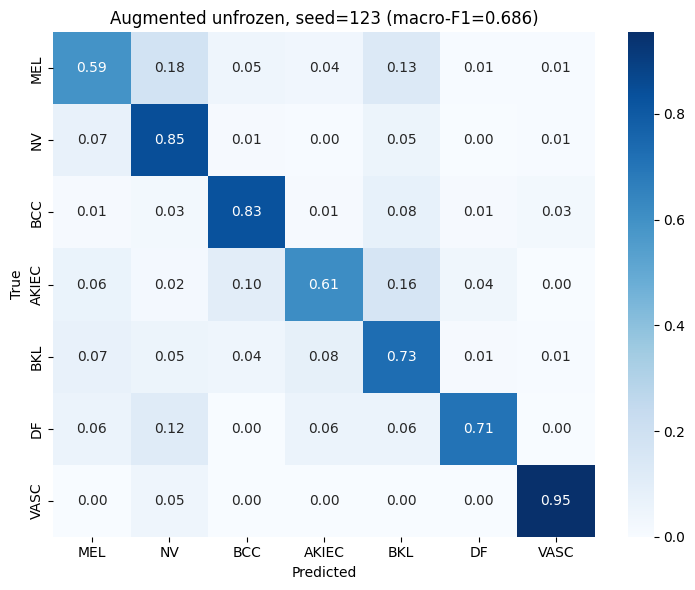

In [14]:
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds, labels=list(range(N_CLASSES)))
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Augmented unfrozen, seed=123 (macro-F1={test_f1:.3f})')

plt.tight_layout()
out = PLOTS_DIR / 'augmented_unfrozen_seed123_confusion.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

MEL is the weakest class at 0.59 recall, with 18% bleeding into NV and 13% into BKL — the same MEL↔NV↔BKL triangle that shows up in every run on this dataset. AKIEC sits at 0.61, leaking 10% to BCC and 16% to BKL. DF holds at 0.71 and VASC at 0.95, both helped by the CVAE synthetic samples in the training set. The error structure mirrors the seed=42 augmented-unfrozen run — no new failure modes from changing the seed.

## 15. Results summary
| metric | seed=42 (Phase 12) | seed=123 (this run) | diff |
|---|---|---|---|
| test macro-F1 (macro-recall overall) | 0.681 | 0.686 | +0.005 |
| largest per-class gain | — | DF +0.059 | |
| largest per-class loss | — | MEL −0.096 | |

The overall macro-F1 spread between seeds is 0.005 — an order of magnitude smaller than the gap between the augmented-unfrozen arm (~0.68) and the unfrozen baseline from notebook 15 (~0.74 ± 0.04). The "augmentation hurts the unfrozen model" finding from Phase 12 is not a seed artefact: under a new seed the augmented-unfrozen run still lands well below the unfrozen-baseline band. Per-class behaviour is also stable — MEL and AKIEC stay the weakest classes, VASC stays near-perfect, and the error structure on the confusion matrix matches seed=42.